#K-Means Clustering (Unsupervised Learning)

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

##Load dataset

In [2]:
iris = load_iris()

In [6]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [7]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

##Convert to dataframe

In [8]:
df = pd.DataFrame(iris.data)
df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


##Let's use two columns

In [9]:
df = df.drop([0,1],axis='columns')

In [10]:
df

,2,3
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


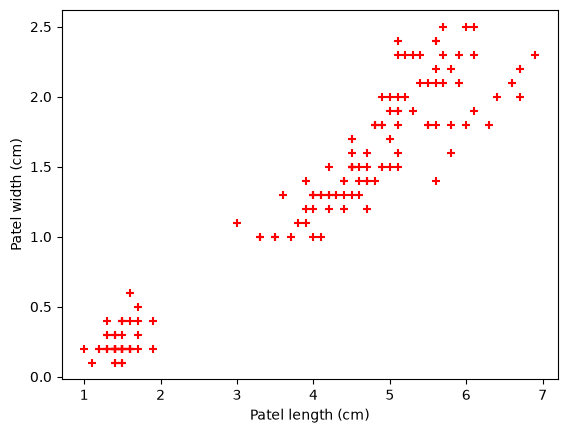

In [11]:
plt.scatter(df[2], df[3] , color = 'red', marker = '+')
plt.xlabel('Patel length (cm)')
plt.ylabel('Patel width (cm)')
plt.show()

## 🔬 Scale a Single Feature Using MinMaxScaler

In this step, we apply `MinMaxScaler` to scale a specific feature of the dataset.

### 🧮 Why MinMaxScaler?
- It scales values **between 0 and 1** (or a custom range).
- Useful for algorithms that are sensitive to feature magnitude (e.g., KMeans, SVM, Neural Networks).


In [12]:
s_length = MinMaxScaler()
s_length.fit(df[[2]])
df[2] = s_length.transform(df[[2]])

df

,2,3
0,0.067797,0.2
1,0.067797,0.2
2,0.050847,0.2
3,0.084746,0.2
4,0.067797,0.2
...,...,...
145,0.711864,2.3
146,0.677966,1.9
147,0.711864,2.0
148,0.745763,2.3


In [13]:
s_width = MinMaxScaler()
s_width.fit(df[[3]])
df[3] = s_width.transform(df[[3]])

df

,2,3
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


In [14]:
model = KMeans(n_clusters=2)
y_predicted = model.fit_predict(df[[2,3]])

y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [15]:
df['predicted'] = y_predicted

df

,2,3,predicted
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1
...,...,...,...
145,0.711864,0.916667,0
146,0.677966,0.750000,0
147,0.711864,0.791667,0
148,0.745763,0.916667,0


In [16]:
df1 = df[df['predicted']==0]
df2 = df[df['predicted']==1]

print(df1)
print(df2)

            2         3  predicted
50   0.627119  0.541667          0
51   0.593220  0.583333          0
52   0.661017  0.583333          0
53   0.508475  0.500000          0
54   0.610169  0.583333          0
..        ...       ...        ...
145  0.711864  0.916667          0
146  0.677966  0.750000          0
147  0.711864  0.791667          0
148  0.745763  0.916667          0
149  0.694915  0.708333          0

[100 rows x 3 columns]
           2         3  predicted
0   0.067797  0.041667          1
1   0.067797  0.041667          1
2   0.050847  0.041667          1
3   0.084746  0.041667          1
4   0.067797  0.041667          1
5   0.118644  0.125000          1
6   0.067797  0.083333          1
7   0.084746  0.041667          1
8   0.067797  0.041667          1
9   0.084746  0.000000          1
10  0.084746  0.041667          1
11  0.101695  0.041667          1
12  0.067797  0.000000          1
13  0.016949  0.000000          1
14  0.033898  0.041667          1
15  0.084746

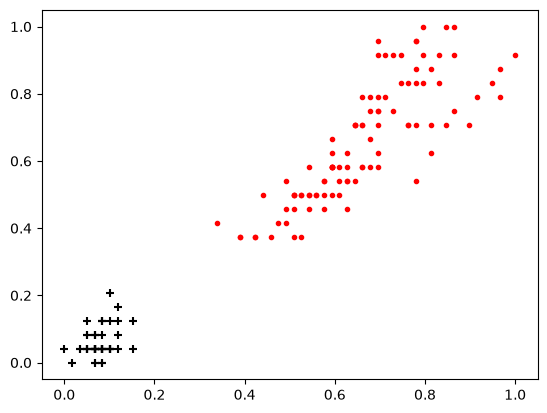

In [17]:
plt.scatter(df1[2], df1[3], color = 'red' , marker ='.')
plt.scatter(df2[2], df2[3], color = 'black' , marker ='+')
plt.show()

In [18]:
df = pd.DataFrame(iris.data)
df


,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [20]:
length = len(df.columns)
length

4

## 📉 Calculate SSE for Different Cluster Counts (Elbow Method)


In [21]:
sse =[]
for i in range(1,length+1):
    km = KMeans(n_clusters=i)
    km.fit(df)
    sse.append(km.inertia_)

print(sse)

[681.3706, 152.34795176035792, 78.8556658259773, 57.38387326549491]


## 🧠 What is the Elbow Method?

The **Elbow Method** is a popular technique used to determine the **optimal number of clusters (K)** for KMeans clustering.

### 📊 How It Works:
1. **KMeans** is applied to the data for a range of values of K (e.g., 1 to 10).
2. For each K, the **SSE (Sum of Squared Errors)** is computed, which represents the compactness of the clusters.
   - This is also called **inertia_** in scikit-learn's KMeans.
3. A line plot is made:  
   - **X-axis**: number of clusters (K)  
   - **Y-axis**: SSE value for each K

### 🎯 Interpretation:
- As the number of clusters increases, SSE naturally decreases.
- At some point, the **rate of decrease sharply slows down**—forming an “elbow” in the plot.
- The **K at this elbow point** is considered the optimal number of clusters because it balances **model complexity and clustering performance**.

The method helps avoid overfitting while achieving good grouping of the data.


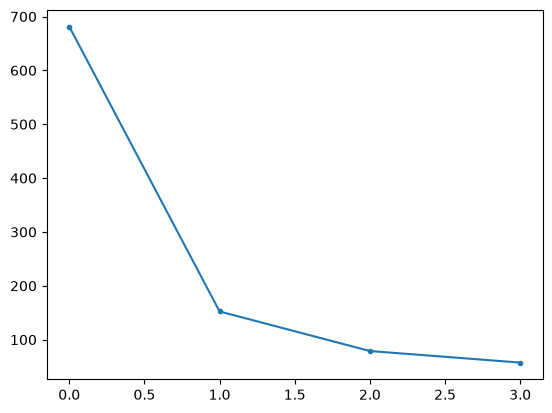

In [22]:
plt.plot(range(length),sse)
plt.scatter(range(length),sse, marker ='.')
plt.show()

##What did you identify from the elbow method? Use elbow method to identify the number of clusters and try applying K-Means on that number of clusters.

#### # the elbow is at 1.0 with SSE near to 150 and next point to elbow is 2 clusters with significantly less sse of under 100


In [23]:
#Code here
# the elbow is at 1.0 with SSE near to 150 and next point to elbow is 2 clusters with significantly less sse of under 100

km = KMeans(n_clusters=2)
km.fit(df)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 4)",